In [1]:
import jax
import optax
import jax.numpy as jnp

In [2]:
jax.config.update("jax_enable_x64", True)

In [3]:
# prompt: a random jnp array of shape [n,D]

key = jax.random.PRNGKey(60415)
n = 10
D = 3
random_array = jax.random.uniform(key, shape=(n,D))
random_array = random_array.at[0].set([1,1,0])
random_array

Array([[1.        , 1.        , 0.        ],
       [0.55010607, 0.66579658, 0.9449229 ],
       [0.24028994, 0.36922518, 0.30399084],
       [0.75187235, 0.435973  , 0.51355789],
       [0.3185389 , 0.71358005, 0.69280556],
       [0.23202114, 0.01575973, 0.45336336],
       [0.67115355, 0.28940574, 0.83170534],
       [0.42358178, 0.75244811, 0.92650312],
       [0.07219383, 0.64678647, 0.39825456],
       [0.08225484, 0.77466181, 0.71970268]], dtype=float64)

In [4]:
def project_and_clip_hypersphere(x):
  x = jnp.clip(x, min=0, max=1)
  return x / jnp.linalg.norm(x,axis=1,keepdims=True)

In [5]:
project_and_clip_hypersphere(random_array)

Array([[0.70710678, 0.70710678, 0.        ],
       [0.4297204 , 0.5200931 , 0.73813518],
       [0.44894255, 0.68983702, 0.56795729],
       [0.74478365, 0.43186262, 0.50871603],
       [0.30501497, 0.6832842 , 0.66339172],
       [0.45536332, 0.03092995, 0.88976827],
       [0.60616087, 0.26138048, 0.75116526],
       [0.33445219, 0.59411885, 0.7315494 ],
       [0.09461982, 0.84770151, 0.5219667 ],
       [0.07755616, 0.73041052, 0.67859083]], dtype=float64)

In [6]:
def project_simplex(x):
  # x = jnp.maximum(0, jnp.minimum(1,x))
  dim = x.shape[-1]
  hyperplane_norm = jnp.ones((dim,)) / jnp.sqrt(dim)
  origin_plane_points = x - hyperplane_norm * jnp.matmul(x, hyperplane_norm[:,None])
  hyperplane_centroid = jnp.ones((dim,)) / dim
  return hyperplane_centroid + origin_plane_points



In [7]:
x = project_simplex(random_array)
x

Array([[ 0.66666667,  0.66666667, -0.33333333],
       [ 0.16316422,  0.27885473,  0.55798105],
       [ 0.26912128,  0.39805653,  0.33282218],
       [ 0.51807127,  0.20217192,  0.27975681],
       [ 0.0768974 ,  0.47193854,  0.45116406],
       [ 0.33163973,  0.11537832,  0.55298195],
       [ 0.40706534,  0.02531753,  0.56761713],
       [ 0.05607078,  0.38493711,  0.55899212],
       [ 0.03311554,  0.60770818,  0.35917628],
       [-0.10995161,  0.58245537,  0.52749623]], dtype=float64)

In [8]:
def clip_simplex(x):
  dim = x.shape[-1]
  hyperplane_centroid = jnp.ones((dim,)) / dim
  x_to_centroid = hyperplane_centroid - x
  expanded_correction_ratios = jnp.where((x>=0.0), 0.0, -x / x_to_centroid)
  correction_ratios = jnp.max(expanded_correction_ratios,axis=1)
  return jnp.clip(x + correction_ratios[:,None] * x_to_centroid, min=0.0, max=1.0)

In [9]:
y = clip_simplex(x)
y

Array([[0.5       , 0.5       , 0.        ],
       [0.16316422, 0.27885473, 0.55798105],
       [0.26912128, 0.39805653, 0.33282218],
       [0.51807127, 0.20217192, 0.27975681],
       [0.0768974 , 0.47193854, 0.45116406],
       [0.33163973, 0.11537832, 0.55298195],
       [0.40706534, 0.02531753, 0.56761713],
       [0.05607078, 0.38493711, 0.55899212],
       [0.03311554, 0.60770818, 0.35917628],
       [0.        , 0.52066359, 0.47933641]], dtype=float64)

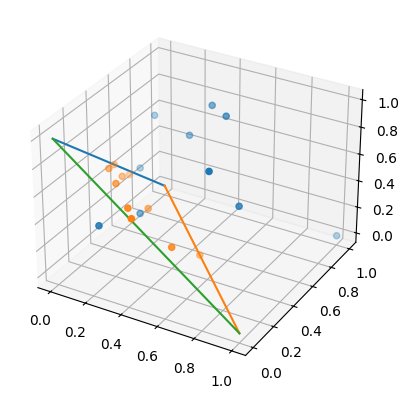

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(random_array[:,0], random_array[:,1], random_array[:,2])
# ax.scatter(x[:,0],x[:,1],x[:,2])
# ax.scatter([0],[0],[0])
ax.scatter(y[:,0],y[:,1],y[:,2])
ax.plot(xs=[0,0], ys=[1,0], zs=[0,1])
ax.plot(xs=[1,0], ys=[0,1], zs=[0,0])
ax.plot(xs=[0,1], ys=[0,0], zs=[1,0])

In [11]:
def project_and_clip_simplex(x):
  return clip_simplex(project_simplex(x))

In [12]:
def distance_matrix(x):
  # l2 norm gives nan grads (because x^0.5 = 0.5*x^-0.5, which is undef when x=0)
  # we avoid this case in computations using jnp.where in reisz_s_energy_loss
  # but apparently, both sides of where need to have non nan grads for it to work sigh
  # https://jax.readthedocs.io/en/latest/faq.html#gradients-contain-nan-where-using-where
  # hence edited everything to use "distance squared matrix"
  return jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=2)

def distance_squared_matrix(x):
  return jnp.sum((x[:,None,:] - x[None,:,:])**2, axis=2)

In [13]:
distance_squared_matrix(y)

Array([[0.        , 0.47370642, 0.17446806, 0.16729201, 0.38335226,
        0.48206806, 0.5561495 , 0.52278481, 0.35858975, 0.48019038],
       [0.47370642, 0.        , 0.07613248, 0.209248  , 0.0561332 ,
        0.05513352, 0.12386172, 0.0227235 , 0.16458059, 0.09127907],
       [0.17446806, 0.07613248, 0.        , 0.10316281, 0.05641337,
        0.13228585, 0.21309159, 0.09671548, 0.10034706, 0.10892518],
       [0.16729201, 0.209248  , 0.10316281, 0.        , 0.29678886,
        0.11694183, 0.12646336, 0.32481993, 0.40594917, 0.4096668 ],
       [0.38335226, 0.0561332 , 0.05641337, 0.29678886, 0.        ,
        0.20239573, 0.32204251, 0.01962989, 0.028812  , 0.00908102],
       [0.48206806, 0.05513352, 0.13228585, 0.11694183, 0.20239573,
        0.        , 0.01401416, 0.14863631, 0.36906602, 0.27966472],
       [0.5561495 , 0.12386172, 0.21309159, 0.12646336, 0.32204251,
        0.01401416, 0.        , 0.25259781, 0.5224649 , 0.41886339],
       [0.52278481, 0.0227235 , 0.0967154

In [14]:
def riesz_s_energy_loss(x, s=-1):
  # think because of https://jax.readthedocs.io/en/latest/faq.html#gradients-contain-nan-where-using-where
  # still need to add the 1e-10 in the knp.where
  distances_sqrd = distance_squared_matrix(x)
  return 0.5 * jnp.sum(jnp.where(distances_sqrd>0, 1/(distances_sqrd**(s/2) + 1e-16), 0))

In [15]:
riesz_s_energy_loss(x)

Array(23.45643246, dtype=float64)

In [16]:
jax.config.update("jax_debug_nans", False)

In [17]:

def generate_evenly_spread_points(num_points, dim, s, project_and_clip_fn, opt_lr, opt_iters, prng_key):
  num_free_points = num_points - dim
  free_points = jax.random.uniform(prng_key, shape=(num_free_points,dim), dtype=jnp.float64)
  free_points = project_and_clip_fn(free_points)

  s = jnp.where(s==-1, dim**2, s)

  def loss_fn(ps):
    return jnp.log(riesz_s_energy_loss(jnp.concatenate((jnp.eye(dim),ps), axis=0), s=s) + 1e-10)

  grad_loss_fn = jax.grad(loss_fn)

  optimizer = optax.adam(opt_lr)
  opt_state = optimizer.init(free_points)

  def loop_fn(iter, loop_state):
    free_points, opt_state = loop_state
    grads = grad_loss_fn(free_points)
    updates, opt_state = optimizer.update(grads, opt_state)
    free_points = optax.apply_updates(free_points, updates)
    free_points = project_and_clip_fn(free_points)
    return (free_points, opt_state)

  free_points, opt_state = jax.lax.fori_loop(0, opt_iters, jax.jit(loop_fn), (free_points, opt_state))

  # for _ in range(opt_iters):
  #   grads = grad_loss_fn(free_points)
  #   updates, opt_state = optimizer.update(grads, opt_state)
  #   free_points = optax.apply_updates(free_points, updates)
  #   free_points = project_and_clip_fn(free_points)

  return jnp.concatenate((jnp.eye(dim),free_points), axis=0)

In [18]:
def plot_points(points):
  fig = plt.figure()
  ax = fig.add_subplot(projection='3d')
  ax.scatter(points[:,0], points[:,1], points[:,2])

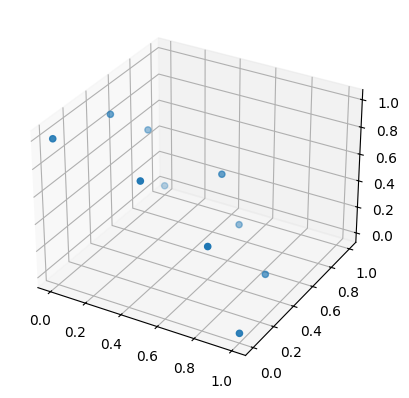

In [19]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=10,
    dim=3,
    s=2,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)
plot_points(sphere_points)

In [20]:
sphere_points

Array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.49767147, 0.86736562],
       [0.52619657, 0.85036296, 0.        ],
       [0.86258704, 0.50590868, 0.        ],
       [0.47535117, 0.        , 0.87979615],
       [0.56203756, 0.60583808, 0.56309324],
       [0.83021403, 0.        , 0.55744476],
       [0.        , 0.84281367, 0.53820546]], dtype=float64)

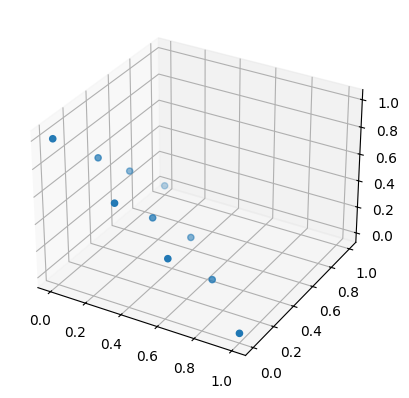

In [21]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=10,
  dim=3,
  s=2,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

In [22]:
simplex_points

Array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 3.78277238e-01, 6.21722762e-01],
       [3.78232462e-01, 6.21767538e-01, 0.00000000e+00],
       [6.63478348e-01, 3.36521652e-01, 0.00000000e+00],
       [3.33885353e-01, 3.33206767e-01, 3.32907880e-01],
       [3.32432951e-01, 1.00738252e-20, 6.67567049e-01],
       [6.17879313e-01, 0.00000000e+00, 3.82120687e-01],
       [0.00000000e+00, 6.62612958e-01, 3.37387042e-01]], dtype=float64)

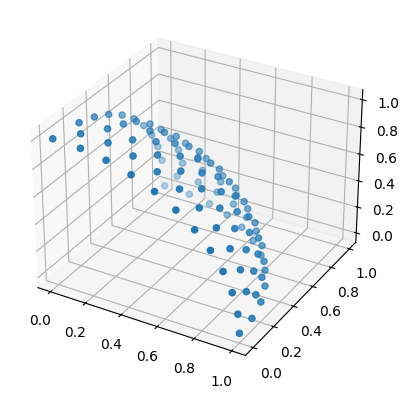

In [23]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=100,
    dim=3,
    s=9,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)

plot_points(sphere_points)

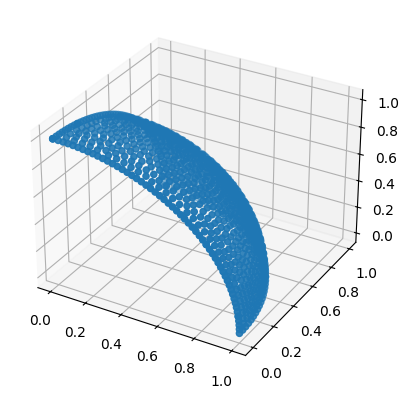

In [24]:
prng_key = jax.random.PRNGKey(60415)
sphere_points = generate_evenly_spread_points(
    num_points=1000,
    dim=3,
    s=9,
    project_and_clip_fn=project_and_clip_hypersphere,
    opt_lr=0.01,
    opt_iters=1000,
    prng_key=prng_key)

plot_points(sphere_points)

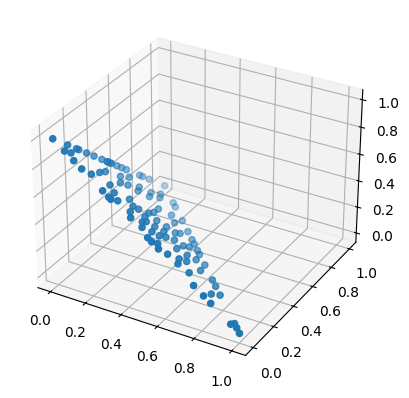

In [25]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=100,
  dim=3,
  s=9,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

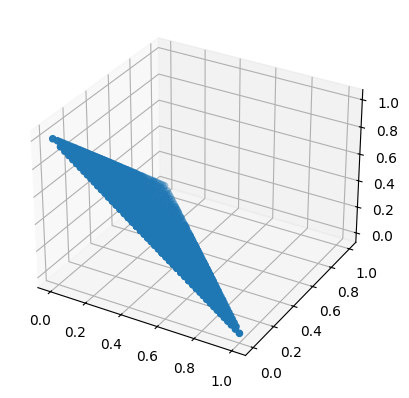

In [26]:
prng_key = jax.random.PRNGKey(60415)
simplex_points = generate_evenly_spread_points(
  num_points=1000,
  dim=3,
  s=9,
  project_and_clip_fn=project_and_clip_simplex,
  opt_lr=0.01,
  opt_iters=1000,
  prng_key=prng_key)

plot_points(simplex_points)

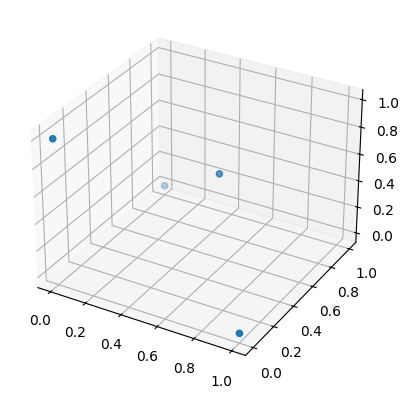

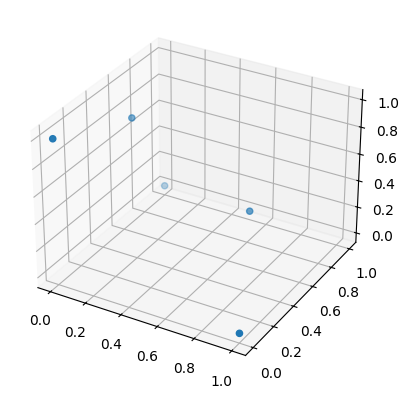

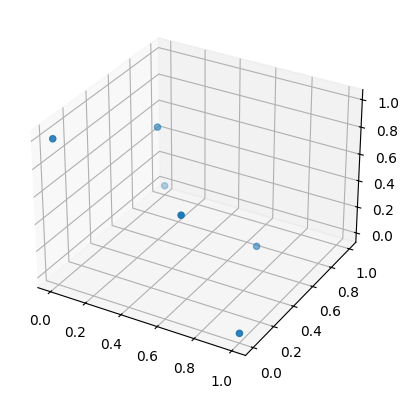

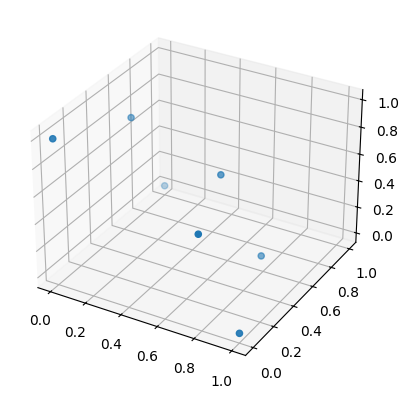

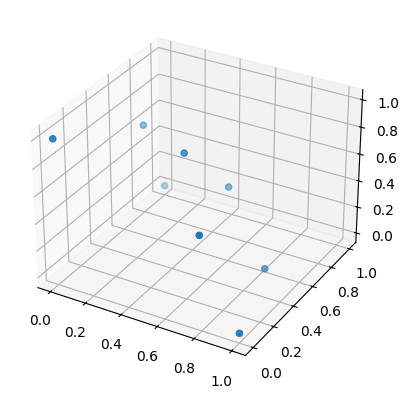

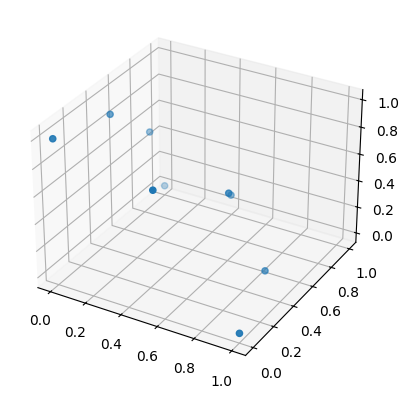

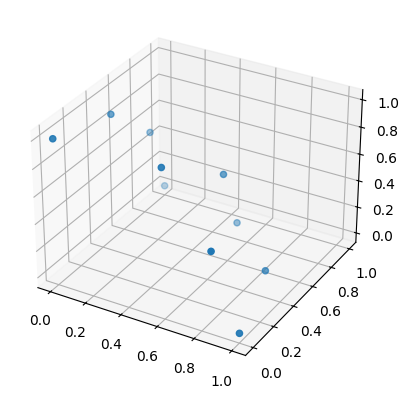

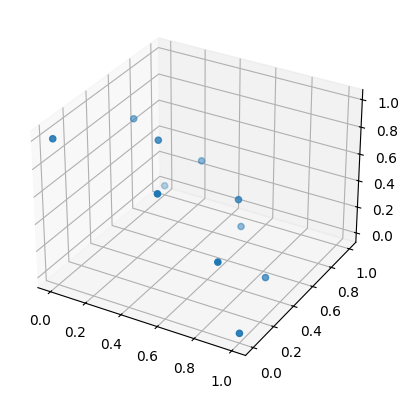

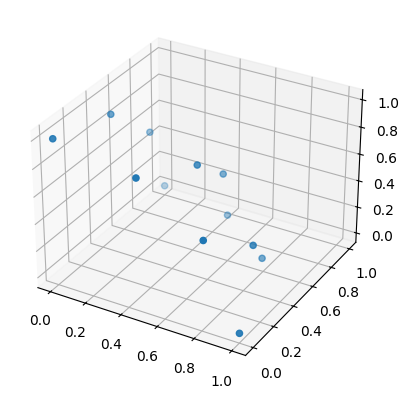

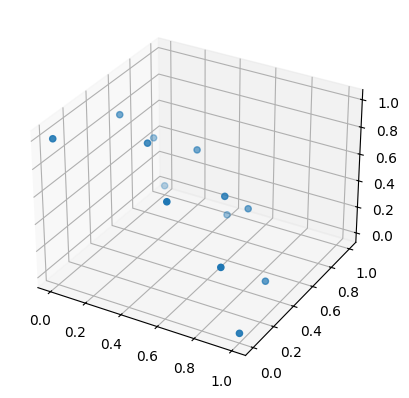

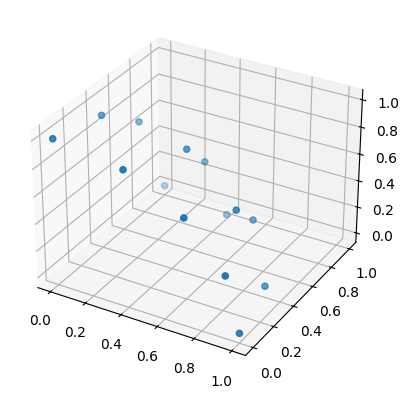

In [27]:
for i in range(4,15):
  prng_key = jax.random.PRNGKey(60415)
  sphere_points = generate_evenly_spread_points(
      num_points=i,
      dim=3,
      s=9,
      project_and_clip_fn=project_and_clip_hypersphere,
      opt_lr=0.01,
      opt_iters=1000,
      prng_key=prng_key)

  plot_points(sphere_points)

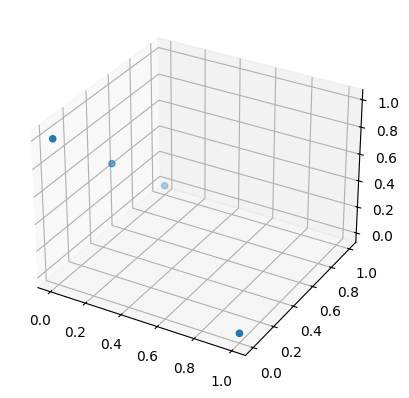

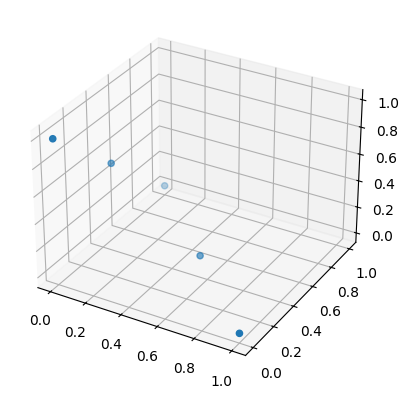

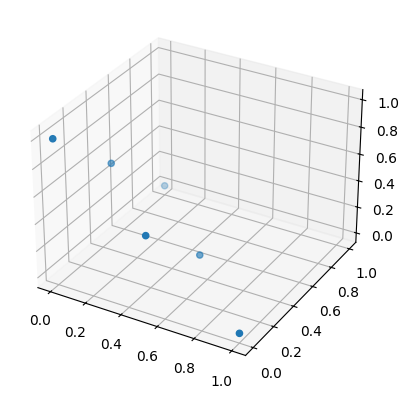

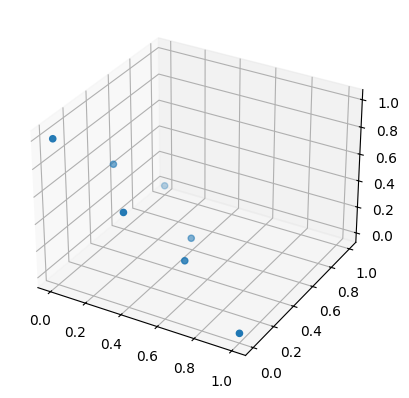

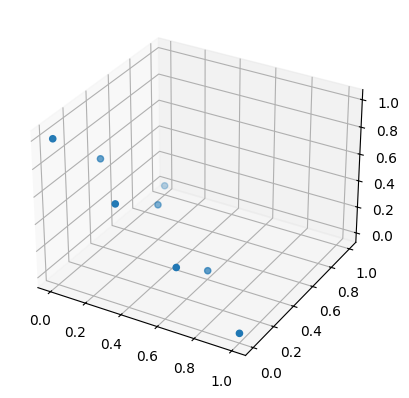

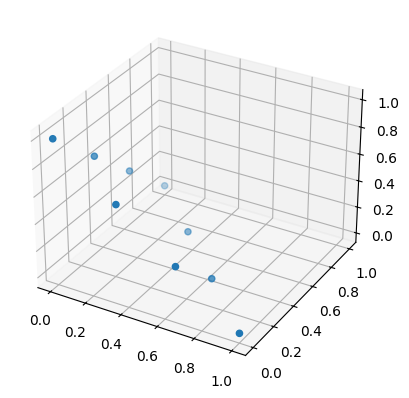

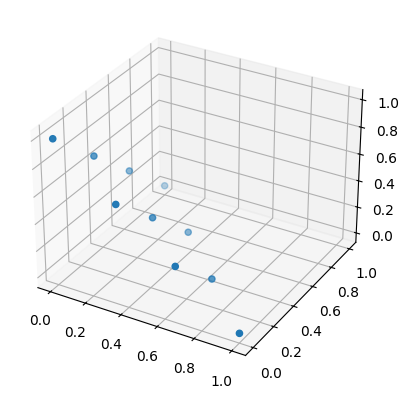

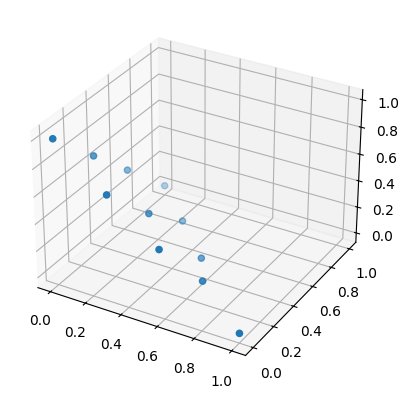

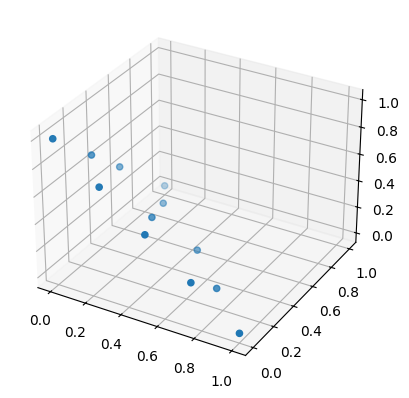

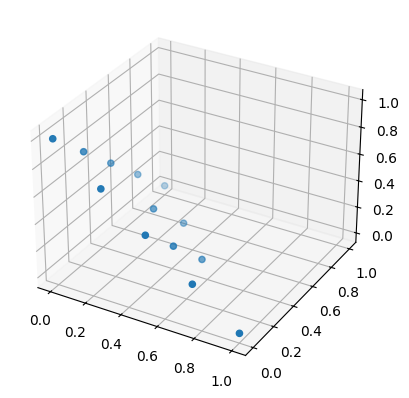

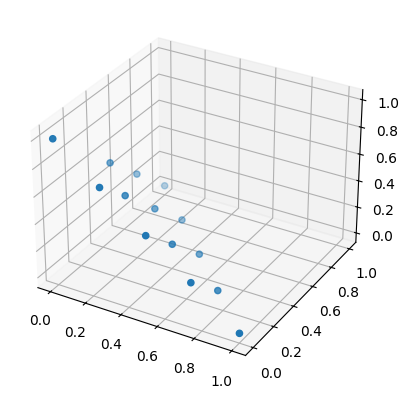

In [28]:
for i in range(4,15):
  prng_key = jax.random.PRNGKey(60415)
  sphere_points = generate_evenly_spread_points(
      num_points=i,
      dim=3,
      s=9,
      project_and_clip_fn=project_and_clip_simplex,
      opt_lr=0.01,
      opt_iters=1000,
      prng_key=prng_key)

  plot_points(sphere_points)

In [29]:
jax.__version__

'0.4.33'

In [30]:
def distances_loss(x):
  return jnp.sum(jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=1))
jax.grad(distances_loss)(x)

Array([[  7.37671988,   5.98028424, -10.74572996],
       [ -1.74058872,  -2.49466702,   3.09109969],
       [  0.77682046,   0.60803971,  -1.5863749 ],
       [  5.45813414,  -4.09950048,  -2.69228314],
       [ -3.47424068,   2.46841969,   1.02531357],
       [  2.21378794,  -5.56942101,   3.00432806],
       [  3.70307949,  -6.87784954,   3.25573575],
       [ -3.83888881,   0.25400545,   3.10853524],
       [ -4.22006657,   5.07490413,  -1.00761391],
       [ -6.25475714,   4.65578484,   2.5469896 ]], dtype=float64)

In [31]:
def distances_loss_err(x):
  return jnp.sum(jnp.linalg.norm(x[:,None,:] - x[None,:,:], axis=-1))
jax.grad(distances_loss_err)(x)

Array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=float64)